# Current version : 10.D (2025-07-23)

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import clear_output
from datetime import datetime

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['#EE2A35', '#009736',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

In [4]:
from module.misc import sample_name_import

name_dir = "circa-SD"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


In [6]:
dir_notebook = '../notebook'
# dir_notebook = 'D:\Jupyter_notebook\Xenium_jupyter_notebook'
name_dir = 'circa-SD'

df = pd.read_parquet(f'{dir_notebook}/csv/circa-SD/circa-SD_norm_combined.parquet')

# Cell Population

In [ ]:
grouped = df.groupby(['run','sample','region_automap_name'])['cell_type_final'].value_counts(dropna=True)
grouped.to_csv('data/cell_count_region.csv')

In [ ]:
import math
df = pd.read_csv('data/cell_count_region.csv')

df = df[df['count'] > 10]

df_nbcells_av = []
df_nbcells_sem = []
df_nbcells_pct = []

all_regions = df['region_automap_name'].unique()
all_celltypes = df['cell_type_final'].unique()

for region in all_regions:
    dat_av = pd.DataFrame()
    dat_sem = pd.DataFrame()
    dat_pct = pd.DataFrame()
    
    for cell in all_celltypes:
        temp_av = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].mean()
        tempdf = pd.DataFrame(data = {cell : temp_av})
        dat_av = pd.concat([dat_av, tempdf], axis=1)

        temp_percent = df[(df['cell_type_final']== cell)& (df['region_automap_name'] == region) ].groupby('run')['count'].sum() / df[df['region_automap_name'] == region].groupby('run')['count'].sum() * 100
        tempdf = pd.DataFrame(data = {cell : temp_percent}) 
        dat_pct = pd.concat([dat_pct, tempdf], axis=1)  

        temp_sem = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].std() / df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].count()
        tempdf = pd.DataFrame(data = {cell : temp_sem})
        dat_sem = pd.concat([dat_sem, tempdf], axis=1)
    
    df_nbcells_sem.append(dat_sem)
    df_nbcells_av.append(dat_av)
    df_nbcells_pct.append(dat_pct)

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_av[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_sem[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_pct[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

In [ ]:
df_average = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', sheet_name=None)
df_std = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', sheet_name=None)
df_pct = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', sheet_name=None)

df_average = {key: value for key, value in sorted(df_average.items())}
df_std = {key: value for key, value in sorted(df_std.items())}
df_pct = {key: value for key, value in sorted(df_pct.items())}


df_average.pop('VLMC')
df_average.pop('Ependymal')
df_average.pop('Choroid')
df_average.pop('Tanycyte')

df_std.pop('Tanycyte')
df_std.pop('VLMC')
df_std.pop('Choroid')
df_std.pop('Ependymal')

df_pct.pop('Tanycyte')
df_pct.pop('VLMC')
df_pct.pop('Choroid')
df_pct.pop('Ependymal')
df_pct.pop('AD')

In [ ]:
for key in df_average.keys():
    df_average[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_average[key].columns]
    df_average[key].index = ['NS','SD']
    df_std[key].index = ['NS','SD']

    plt.figure(figsize=(5,8))
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T['NS'],
           height= 0.45, align='edge', label = 'NS',edgecolor='black',
           xerr= df_std[key].T['NS'] 
           )
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T['SD'],
           height= -0.45, align='edge', label = 'SD',edgecolor='black',
           xerr= df_std[key].T['SD'] )
    plt.xlabel('Average cell number')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig('Gallery/circa-SD_cellnb.svg')
    clear_output()

In [ ]:
len(df_pct[key])

In [ ]:
for key in df_pct.keys():
    if len(df_pct[key]) == 1:
        continue
    df_pct[key] = df_pct[key][df_pct[key].select_dtypes(np.number).gt(0.5)]
    df_pct[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_pct[key].columns]
    df_pct[key].index = ['NS','SD']
    df_std[key].index = ['NS','SD']

    plt.figure(figsize=(5,8))
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['NS'],
           height= 0.45, align='edge', label = 'NS',edgecolor='black',
           )
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['SD'],
           height= -0.45, align='edge', label = 'SD',edgecolor='black',
           )
    plt.xlabel('Percentage cells')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig('Gallery/circa-SD_cellnb.svg')
    clear_output()

# Expressed genes

In [ ]:
df_NS = df[(df['run']=='circa4')]
df_SD = df[(df['run']=='SD1')]
del df

In [ ]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k')
dict_pos = {}

gene_columns = df_SD[clock_genes]
grouped = df_SD.groupby('cell_type_final')


for cell_type, group in grouped:
    gene_presence_pct = group.iloc[:, :-1].mean()
    expressed_genes = gene_presence_pct[gene_presence_pct >= 0.01].index.tolist()
    dict_pos[cell_type] = expressed_genes


In [ ]:
gene_nb = [len(dict_pos[key]) for key in dict_pos.keys()]
gene_nb

In [ ]:
gene_nb.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

# Cycling genes

In [ ]:
import pandas as pd

In [ ]:
df_circa2 = pd.read_excel('data/cyc_analysis_nonzero_circa2.xlsx', sheet_name = 'sig_cyl_gene')
df_circa4 = pd.read_excel('data/cyc_analysis_nonzero_circa4.xlsx', sheet_name = 'sig_cyl_gene')

In [ ]:
circa4_gene = set(df_circa4['CycID'])
circa2_gene = set(df_circa2['CycID'])

In [ ]:
common_genes = circa4_gene.intersection(circa2_gene)

In [ ]:
len(common_genes), len(circa4_gene),len(circa2_gene)

In [ ]:
# library
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Use the venn2 function
venn2(subsets = (1449, 846, 560), set_labels = ('IGM', 'Salk'))
plt.show()


## Polar plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': ['Arntl', 'Clock', 'Cry1', 'Cry2','Npas2', 'Nr1d1', 'Per2', 'Per3','Rorc',
                            'Arntl','Clock','Cry1','Nr1d1','Per1','Per2','Per3','Rorc'
                            ],
                    'Phase': [1.00, 8.38, 15.31, 12.89, 22.56, 8.96,15.30,13.06,16.54,
                              1.00, 3.15, 16.75, 9.02, 11.92, 16.23, 14.17, 17.06
                            ]
                    })

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

ax.set_yticks(range(1, len(gene_order) + 1))
ax.set_yticklabels(gene_order)
ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left", title='Gene')

plt.tight_layout()
plt.show()

## Cell type spe polar

In [ ]:
import pandas as pd

dir_sum = '../R/Results/2025-06-25_circa4_celltype/Summary'

df = pd.read_excel(f'{dir_sum}/2025-06-25_circa4_cyc_siggene_by_celltype.xlsx', sheet_name=None, usecols=['CycID', 'meta2d_phase'])

In [ ]:
clockgenelist=['Arntl', 'Clock', 'Cry1', 'Cry2', 'Npas2', 'Nr1d1', 'Per1', 'Per2', 'Per3', 'Rora', 'Rorb', 'Rorc']
dataset = pd.DataFrame()
for key in df.keys():
    subdf = df[key].filter(['CycID', 'meta2d_phase'], axis=1)
    subdf = subdf[subdf['CycID'].isin(clockgenelist)]
    dataset = pd.concat([dataset, subdf])

In [ ]:
all_celltype_CG = dict(zip(dataset['CycID'], dataset['meta2d_phase']))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

## Histo polar plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
run_namdate = "2025-06-25_circa4"
run_type = 'celltype'

dir_sum = f'../R/Results/{run_namdate}_{run_type}/Summary'

df_all = pd.read_excel(f'{dir_sum}/{run_namdate}_cyc_siggene_by_celltype.xlsx', sheet_name=None)
cycling_summary = pd.read_csv(f'{dir_sum}/{run_namdate}_cycling_gene_count_by_celltype.csv', index_col='cycling_gene_count')

In [ ]:
cycling_summary.iloc[1]

In [ ]:
for idx, celltype in enumerate(df_all.keys()):

    # Data preparation
    df = pd.DataFrame(data=zip(df_all[celltype]['CycID'], df_all[celltype]['meta2d_phase']))
    df.columns = ['Gene','Phase']
    df['Radians'] = df['Phase'] / 24 * 2 * np.pi

    # Plot
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.grid(True)

    ax.hist(df['Radians'], bins = 24)

    ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
    ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

    plt.title(f'Genes Phase in {celltype}')
    plt.savefig(f'Gallery/circa4/polar_gene_{celltype}.svg')
    plt.show()
    plt.close()


### Histo polar in region/gene panel

In [ ]:
import pandas as pd
from module.misc import genes_list

gene_list = genes_list('mitochondria')
region = 'SCH'
df_all = pd.read_excel(f'data/{region}_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from module.misc import genes_list

region = 'SCH'
df_all = pd.read_excel(f'data/SCH_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')
gene_list = genes_list('mitochondria')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

## Phase comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
run_namdate_1 = "2025-06-26_circa4"
run_namdate_2 = "2025-06-26_SD1"
run_type = 'celltype'
cell_type_plot = 'Ependymal'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

df_all_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)
df_all_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)

In [ ]:
from module.misc import genes_list

gene_list_plot = genes_list("clock")

dataset_NS = pd.DataFrame()

subdf_all_NS = df_all_NS.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_NS = subdf_all_NS[subdf_all_NS['CycID'].isin(gene_list_plot)]
dataset_NS = pd.concat([dataset_NS, subdf_all_NS])

dataset_SD = pd.DataFrame()
subdf_all_SD = df_all_SD.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_SD = subdf_all_SD[subdf_all_SD['CycID'].isin(gene_list_plot)]
dataset_SD = pd.concat([dataset_SD, subdf_all_SD])

In [ ]:
data = pd.DataFrame(index=gene_list_plot)

In [ ]:
all_celltype_NS = dict(zip(dataset_NS['CycID'], dataset_NS['meta2d_phase']))
all_celltype_SD = dict(zip(dataset_SD['CycID'], dataset_SD['meta2d_phase']))

In [ ]:
data['NS'] = data.index.map(all_celltype_NS)
data['SD'] = data.index.map(all_celltype_SD)
# data.dropna(inplace= True)
data['Gene'] = data.index
data['Diff'] = data['NS'] - data['SD']
data = data.sort_values(by='NS')

In [ ]:

data['NS2'] = data['NS']
data['SD2'] = data['SD']

# for n in range(len(data)):
#     if data.iloc[n,data.columns.get_loc("Diff")] > 12:
#         if data.iloc[n,data.columns.get_loc("NS")] < data.iloc[n,data.columns.get_loc("SD")]:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")] + 24
#         else:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
#     else:
#         data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]
#         data.iloc[n,data.columns.get_loc("SD")] = data.iloc[n,data.columns.get_loc("SD")]
thres = 12

for n in range(len(data)):
    if (abs(data.iloc[n,data.columns.get_loc("Diff")]) >= thres):
        if (data.iloc[n,data.columns.get_loc("SD")] > data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]-24
        elif (data.iloc[n,data.columns.get_loc("SD")] < data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
    else:
        data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]
        data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]

# data = data.sort_values(by="Diff", ascending=False)
data = data.sort_index()

In [ ]:
data

In [ ]:
# Convert phase to radians for polar plot
data['Radians_NS'] = data['NS'] / 24 * 2 * np.pi
data['Radians_SD'] = data['SD'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data.index
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data.index.map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

# Plot
plt.figure(figsize=(5,5))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data.index == gene]
    ax.scatter(subset['Radians_NS'], subset['Radius'], label=gene, color=gene_colors[gene], s=40, edgecolors='black')
    ax.scatter(subset['Radians_SD'], subset['Radius'], color=gene_colors[gene], alpha = 0.5, s=40)

ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])
ax.set_ylabel(ylabel=None)
plt.title('Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
# Color palette
gene_order = data.index
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

In [ ]:
# data = data[0:20]

In [ ]:
plt.figure(figsize=(3,4))
ax =ax = plt.subplot()

for n in range(len(data)):
    ax.hlines(y=n, xmin=data.iloc[n,data.columns.get_loc("NS2")], xmax=data.iloc[n,data.columns.get_loc("SD2")], linestyles='dashed', color = 'black')
    ax.scatter(x=data.iloc[n,data.columns.get_loc("NS2")],y=n,
               color = data.iloc[n,data.columns.get_loc("Color")],
                 edgecolors='black', label = data.index.values[n])
    ax.scatter(x=data.iloc[n,data.columns.get_loc("SD2")], y=n, color = data.iloc[n,data.columns.get_loc("Color")])
ax.set_xlim(0,24)
ax.set_ylim(-0.25, len(data)-0.75)
ax.set_xticks([0,4,8,12,16,20,24])
ax.set_xlabel('ZT')
ax.set_yticks(ticks = range(len(data)),labels = data['Gene'])
ax.vlines(x = [0,12,24], ymin=0, ymax=len(data), color = 'darkgrey', linestyles='dashed')
ax.invert_yaxis()
plt.tight_layout()

# plt.legend()

## Barplot

In [15]:
df_gen_NS = pd.read_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv', index_col="Celltype")
df_gen_SD = pd.read_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv', index_col="Celltype")

In [16]:
df_gen_NS.to_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv')
df_gen_SD.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

In [17]:
run_namdate_1 = "2025-07-21_circa4"
run_namdate_2 = "2025-07-21_SD1"
run_type = 'celltype'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

cycling_summary_1 = pd.read_csv(f'{dir_sum_1}/{run_namdate_1}_cycling_gene_per_group.csv', index_col='celltype')
cycling_summary_2 = pd.read_csv(f'{dir_sum_2}/{run_namdate_2}_cycling_gene_per_group.csv', index_col='celltype')

In [18]:
NS_dict = dict(zip(cycling_summary_1.index,cycling_summary_1['cycling_gene_count']))
SD_dict = dict(zip(cycling_summary_2.index,cycling_summary_2['cycling_gene_count']))

df_gen_NS['Cycling_pval'] = df_gen_NS.index.map(NS_dict)
df_gen_SD['Cycling_pval'] = df_gen_SD.index.map(SD_dict)

In [19]:
df_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])
df_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])


common = {}
sum_com = {}
common_cells = set(df_NS.keys()).intersection(set(df_SD.keys()))

for key in common_cells:
    # df_NS[key] = df_NS[key][df_NS[key]['meta2d_BH.Q']>=0.05]
    # df_SD[key] = df_SD[key][df_SD[key]['meta2d_BH.Q']>=0.05]
    common[key] = df_NS[key][df_NS[key]['CycID'].isin(df_SD[key]['CycID'])]
    sum_com[key] = len(common[key])

sum_com_df = pd.DataFrame({'Gene': sum_com.keys(),
                    'Common': sum_com.values()})
sum_com_df.index = sum_com_df['Gene']

In [20]:
sum_com_dict = dict(zip(sum_com_df['Gene'],sum_com_df['Common']))
df_gen_NS['Common_pval'] = df_gen_NS.index.map(sum_com_dict)
df_gen_SD['Common_pval'] = df_gen_SD.index.map(sum_com_dict)


In [21]:
df_NS_BH_nb = [len(df_NS[key]) for key in df_NS.keys()]
ddf_NS_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_NS_BH_nb}, index = df_NS.keys())

df_SD_BH_nb = [len(df_SD[key]) for key in df_SD.keys()]
ddf_SD_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_SD_BH_nb}, index = df_SD.keys())

NS_BH_dict = dict(zip(ddf_NS_BH_nb.index, ddf_NS_BH_nb['Expressed_genes']))
df_gen_NS['Cycling_BH'] = df_gen_NS.index.map(NS_BH_dict)

SD_BH_dict = dict(zip(ddf_SD_BH_nb.index, ddf_SD_BH_nb['Expressed_genes']))
df_gen_SD['Cycling_BH'] = df_gen_SD.index.map(SD_BH_dict)

In [22]:
cycling_summary_1 = cycling_summary_1[cycling_summary_1.index.isin(cycling_summary_2.index)].sort_values(by='cycling_gene_count')
cycling_summary_2 = cycling_summary_2[cycling_summary_2.index.isin(cycling_summary_1.index)]

In [49]:
cycling_summary_1.index

Index(['SMC', 'Sncg Gaba', 'STR Gaba', 'PAL STR Gaba Chol',
       'L2 3 PIR ENTl Glut', 'MEA Glut', 'OB STR CTX IMN', 'L5 NP CTX Glut',
       'COAa PAA MEA Glut', 'Vip Gaba', 'Lamp5 Gaba', 'DG Glut', 'ABC',
       'STR PAL Gaba', 'PVH Glut', 'L6b CTX Glut', 'AHN Glut', 'SCH Gaba',
       'Sst Gaba', 'VLMC', 'L5 ET CTX Glut', 'Pericyte', 'LHA Glut',
       'Ependymal', 'Pvalb Gaba', 'Microglia', 'OPC', 'L2 3 IT PIR ENTl Glut',
       'STR D1 Gaba', 'L6 CT CTX Glut', 'Endothelial', 'Oligodendrocyte',
       'L4 5 IT CTX Glut', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE'],
      dtype='object', name='celltype')

In [23]:
df_gen_NS.sort_values(by='Common_pval',inplace=True)
df_gen_SD
df_gen_NS.dropna(axis=0, inplace= True)
df_gen_SD.dropna(axis=0, inplace= True)

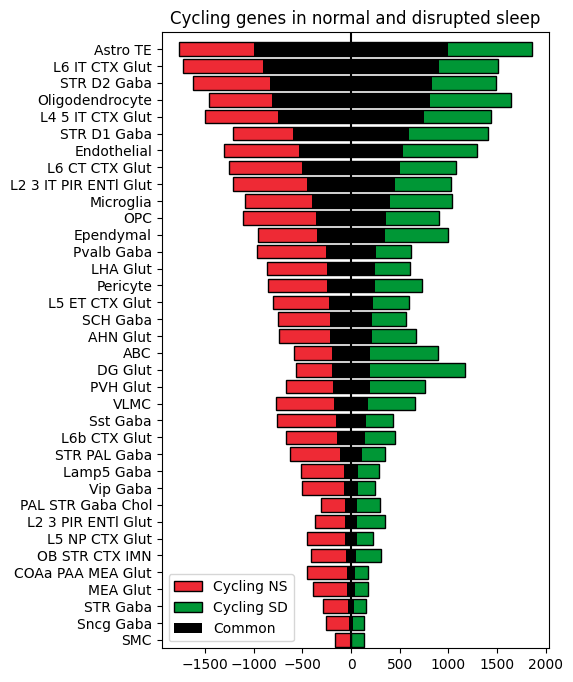

In [31]:
fig, ax = plt.subplots(figsize = (5,8))
# ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Count'], label = 'Expressed', color = 'None', edgecolor ='black')
# ax.barh(y = df_gen_SD.index, width = df_gen_SD['Count'], color = 'None', edgecolor = 'black')
ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Cycling_pval'], edgecolor = 'black', label = 'Cycling NS')
ax.barh(y = df_gen_SD.index, width= df_gen_SD['Cycling_pval'], edgecolor = 'black', label = 'Cycling SD')
ax.barh(y = df_gen_NS.index, width=df_gen_NS['Common_pval'], label = 'Common', color = 'black')
ax.barh(y = df_gen_SD.index, width=-df_gen_SD['Common_pval'], color = 'black')
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS))
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep')
plt.savefig(f'Gallery/{today}/Cycling_genes_overview.svg',dpi=300)

In [25]:
len(df_gen_SD.index)

36

In [37]:
order_list =[
        "Oligodendrocyte","Microglia","Endothelial","SMC","Pericyte","VLMC","ABC",
        "Ependymal", "OB STR CTX IMN","OPC","Astro TE", "SCH Gaba","PVH Glut","AHN Glut","PAL STR Gaba Chol","MEA Glut","LHA Glut",
    "Pvalb Gaba","STR Gaba","Sst Gaba","Sncg Gaba","Vip Gaba","Lamp5 Gaba","L6 IT CTX Glut","L4 5 IT CTX Glut","L5 ET CTX Glut",
    "L5 NP CTX Glut","L6b CTX Glut","L6 CT CTX Glut","L2 3 PIR ENTl Glut","L2 3 IT PIR ENTl Glut","COAa PAA MEA Glut",
    "DG Glut","STR PAL Gaba","STR D1 Gaba","STR D2 Gaba",]


cycling_summary_1_sort = cycling_summary_1.reindex(order_list)
cycling_summary_1_sort.dropna(axis=0, inplace=True)
cycling_summary_1_sort = cycling_summary_1_sort.reindex(sorted(cycling_summary_1_sort.columns), axis=1)
cycling_summary_1_sort.head(2)

,cycling_gene_count
celltype,
Oligodendrocyte,1455
Microglia,1087


In [46]:
df_gen_NS_sort =df_gen_NS.reindex(order_list)
df_gen_SD_sort = df_gen_SD.reindex(order_list)
df_gen_NS_sort.dropna(axis=0, inplace= True)
df_gen_SD_sort.dropna(axis=0, inplace= True)
cycling_summary_2_sort = cycling_summary_2.reindex(order_list)
cycling_summary_2_sort.dropna(axis=0, inplace=True)

In [47]:
len(df_gen_NS_sort),len(df_gen_SD_sort),len(cycling_summary_1_sort),len(cycling_summary_2_sort)

(36, 36, 36, 36)

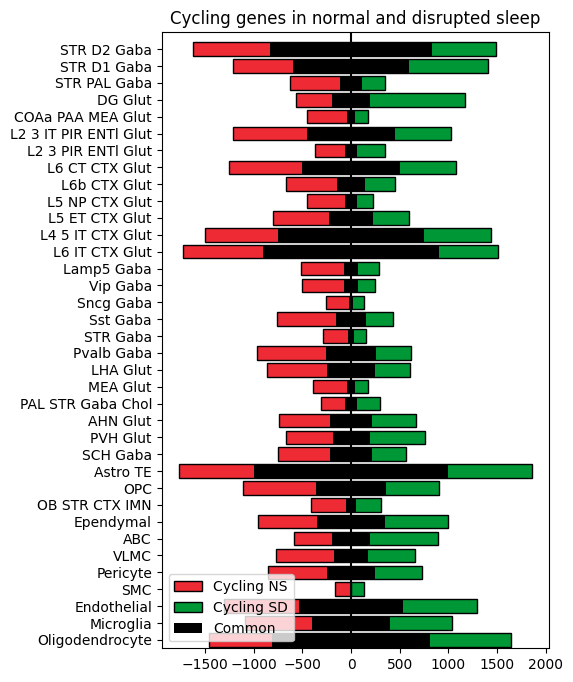

In [48]:
fig, ax = plt.subplots(figsize = (5,8))
# ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Count'], label = 'Expressed', color = 'None', edgecolor ='black')
# ax.barh(y = df_gen_SD.index, width = df_gen_SD['Count'], color = 'None', edgecolor = 'black')
ax.barh(y = df_gen_NS_sort.index, width = -df_gen_NS_sort['Cycling_pval'], edgecolor = 'black', label = 'Cycling NS')
ax.barh(y = df_gen_SD_sort.index, width= df_gen_SD_sort['Cycling_pval'], edgecolor = 'black', label = 'Cycling SD')
ax.barh(y = df_gen_NS_sort.index, width=df_gen_NS_sort['Common_pval'], label = 'Common', color = 'black')
ax.barh(y = df_gen_SD_sort.index, width=-df_gen_SD_sort['Common_pval'], color = 'black')
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS_sort), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS_sort))
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep')
plt.savefig(f'Gallery/{today}/Cycling_genes_overview_dendro.svg',dpi=300)

## Cycling genes correlation

In [148]:
run_namdate = "2025-07-21_circa4"
run_type = 'celltype'

dir_sum = f'../R/Results/{run_namdate}_{run_type}/Summary'

df_all = pd.read_excel(f'{dir_sum}/{run_namdate}_cyc_siggene_analysis.xlsx', sheet_name=None)

In [149]:
from module.misc import genes_list

gens = genes_list('panel_5k')

df_genes = pd.DataFrame(data={"Gene" : gens}, index= gens)


for key in df_all.keys():
    df_genes[key] = np.zeros(len(df_genes))

    for gene in df_all[key]['CycID'].unique():
        df_genes.loc[gene,key] +=1



In [150]:
df_genes.drop('Gene',axis=1, inplace=True)

In [151]:
order_list = ['SMC', 'Sncg Gaba', 'STR Gaba', 'PAL STR Gaba Chol',
       'L2 3 PIR ENTl Glut', 'MEA Glut', 'OB STR CTX IMN', 'L5 NP CTX Glut',
       'COAa PAA MEA Glut', 'Vip Gaba', 'Lamp5 Gaba', 'DG Glut', 'ABC',
       'STR PAL Gaba', 'PVH Glut', 'L6b CTX Glut', 'AHN Glut', 'SCH Gaba',
       'Sst Gaba', 'VLMC', 'L5 ET CTX Glut', 'Pericyte', 'LHA Glut',
       'Ependymal', 'Pvalb Gaba', 'Microglia', 'OPC', 'L2 3 IT PIR ENTl Glut',
       'STR D1 Gaba', 'L6 CT CTX Glut', 'Endothelial', 'Oligodendrocyte',
       'L4 5 IT CTX Glut', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE']

df_genes_sort = df_genes.loc[:, order_list]

In [152]:
df_corr = df_genes_sort.corr(method='spearman')

In [153]:
df_corr.min().min()

0.060960927503187094

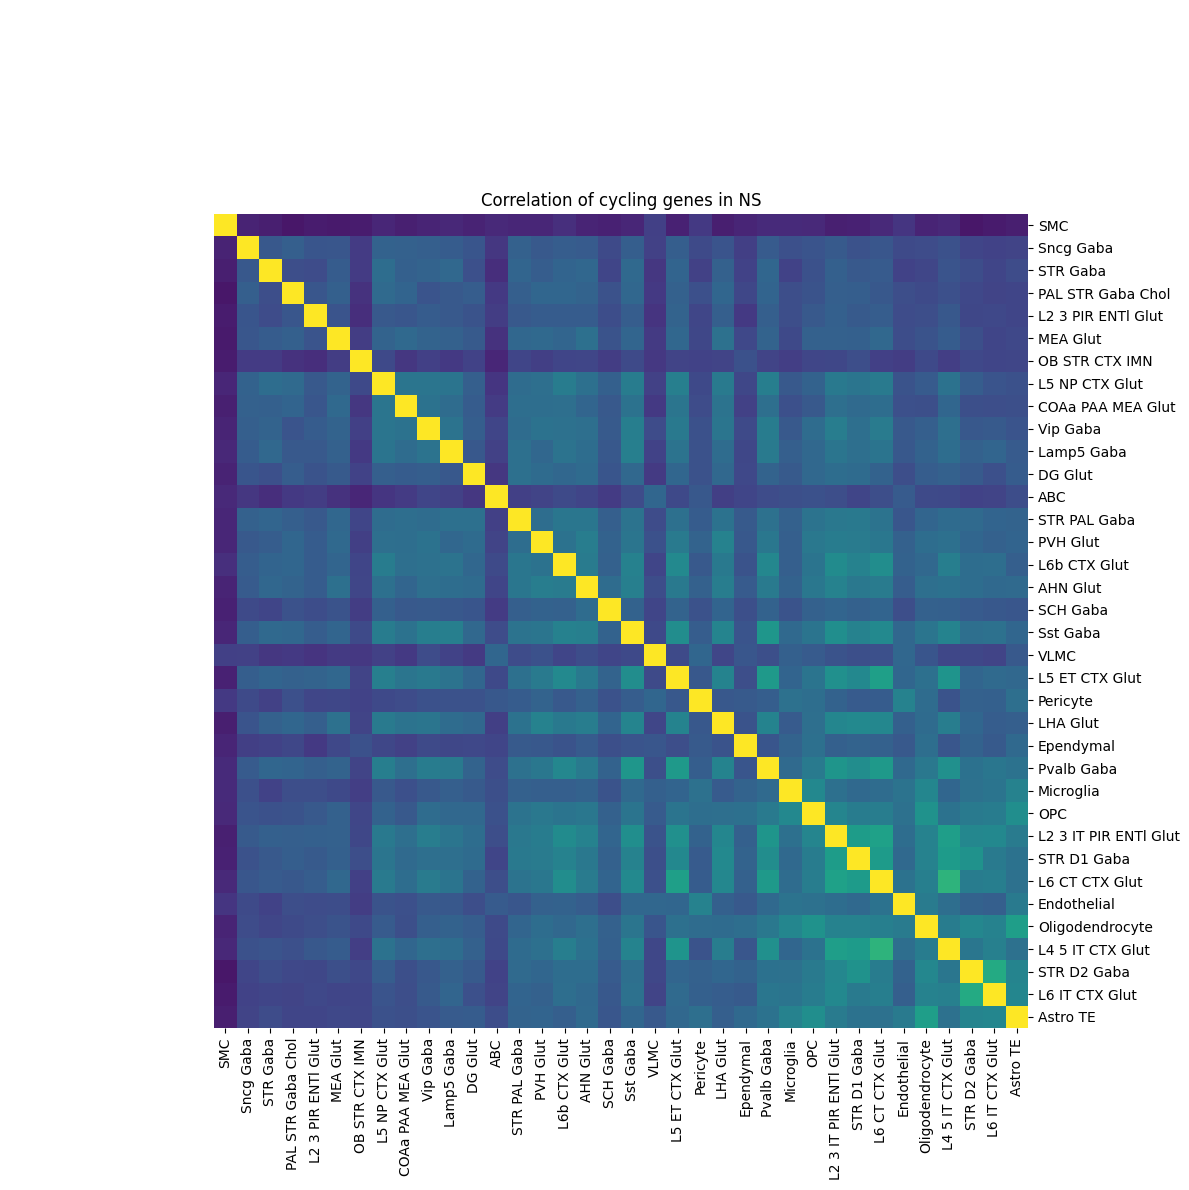

In [ ]:
import seaborn as sns
df_corr
sns.clustermap(df_corr, cmap = 'viridis', vmin=0,vmax=1,
                col_cluster=False,row_cluster=False, cbar = False, cbar_pos=None,figsize=(12, 12),
                )
plt.title('Correlation of cycling genes in NS')
# plt.savefig(f'Gallery/{today}/NS_corr_cyclinggenes_ordernbcycgenes.svg',dpi=300)

# Test Squidpy

## Data Import

In [1]:
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np

In [101]:
dir_notebook = '/media/volume/volume_spatial/hugo/notebook'
name_dir = "circa-SD"
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')
# adata_bis = sc.read_h5ad(r'..\..\h5ad\run3-SC\run3-SC_clusters.h5ad.gz')


In [102]:
# adata = adata[adata.obs['sample'] == 'SD1-ZT01']
adata = adata[adata.obs['run'] == "circa4"] 
# adata_bis = adata_bis[adata_bis.obs['sample'] == '3161-3']
# adata = adata[adata.obs['region_automap_name']=='SCH']
# adata.obsm['spatial'] = adata.obsm['coord_xy']

In [63]:
adata

View of AnnData object with n_obs × n_vars = 776348 × 5006
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_counts', 'batch', 'sample', 'mmc:class_name', 'mmc:class_correlation_coefficient', 'mmc:subclass_name', 'mmc:supertype_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'run', 'leiden', 'cell_type_auto', 'cell_class_auto', 'cell_type_newnum_auto', 'cell_class_newnum_auto', 'cell_type_auto_sub', 'cell_type_newnum_auto_sub', 'cell_type_final', 'cell_type_newnum_final', 'region_automap_name', 'region_automap_num', 'cell_class', 'cell_class_newnum', 'circascore', 'ZT', 'umap-1', 'umap-2', 'umap-3',

In [20]:
adata.obsm['spatial'] = adata_bis.obsm['spatial'] 

C:\Users\hcall\AppData\Local\Temp\ipykernel_6412\3505080216.py:1: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  adata.obsm['spatial'] = adata_bis.obsm['spatial']


In [64]:
adata

View of AnnData object with n_obs × n_vars = 776348 × 5006
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_counts', 'batch', 'sample', 'mmc:class_name', 'mmc:class_correlation_coefficient', 'mmc:subclass_name', 'mmc:supertype_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'run', 'leiden', 'cell_type_auto', 'cell_class_auto', 'cell_type_newnum_auto', 'cell_class_newnum_auto', 'cell_type_auto_sub', 'cell_type_newnum_auto_sub', 'cell_type_final', 'cell_type_newnum_final', 'region_automap_name', 'region_automap_num', 'cell_class', 'cell_class_newnum', 'circascore', 'ZT', 'umap-1', 'umap-2', 'umap-3',

In [138]:
adata_sub = adata[adata.obs["region_automap_name"]=='CTX']

In [139]:
adata_sub.obs.sample()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,region_automap_num,cell_class,cell_class_newnum,circascore,ZT,umap-1,umap-2,umap-3,umap-4,Neurotransmitter
circa4-IGM-ZT21_ckobaifd-1,circa4-IGM-ZT21_ckobaifd-1,8905.464844,4499.772949,679,0,0,0,0,0,679.0,...,0,Neuronal,1,2,ZT21,2.406161,12.198018,2.406161,12.198018,Glutamate


## Spatial correlation

In [58]:
sq.gr.spatial_neighbors(adata_sub)

In [59]:
sq.gr.nhood_enrichment(adata_sub, cluster_key="cell_type_final")

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/gr/_utils.py:136: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):


  0%|          | 0/1000 [00:00<?, ?/s]

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/gr/_nhood.py:182: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/gr/_utils.py:136: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/gr/_utils.py:136: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_utils.py:555: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

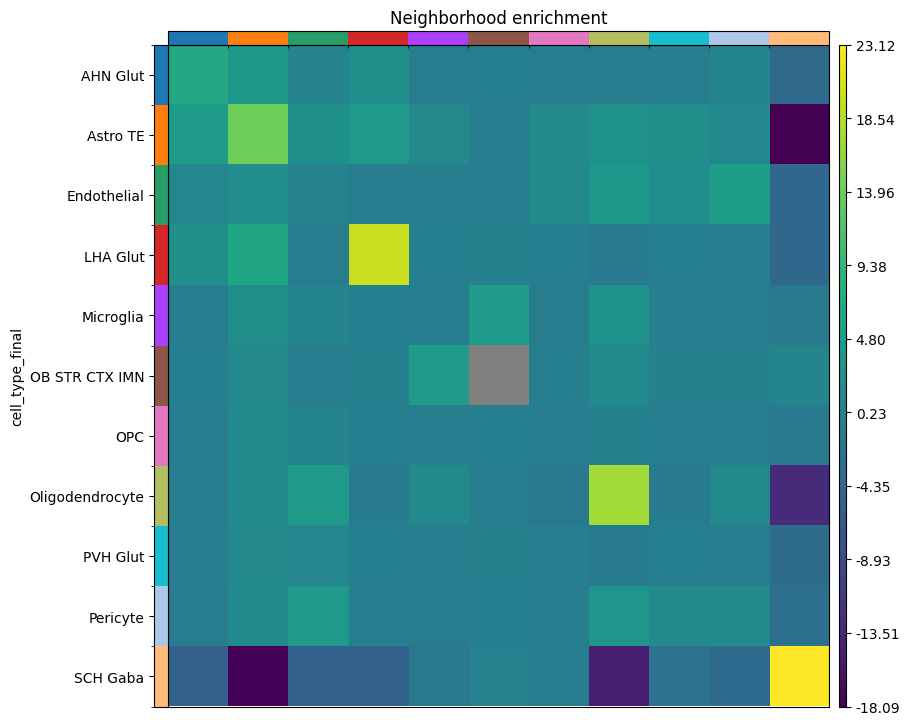

In [60]:
sq.pl.nhood_enrichment(adata_sub, cluster_key="cell_type_final")

## Moran

In [56]:
sq.gr.spatial_neighbors(adata_sub, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_sub,
    mode="moran",
    n_perms=100,
    n_jobs=5,
)
adata_sub.uns["moranI"].head(15)

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/metrics/_gearys_c.py:293: UserWarning: 612 variables were constant, will return nan for these.
  warnings.warn(


  0%|          | 0/100 [00:00<?, ?/s]

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/metrics/_gearys_c.py:293: UserWarning: 612 variables were constant, will return nan for these.
  warnings.warn(
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/metrics/_gearys_c.py:293: UserWarning: 612 variables were constant, will return nan for these.
  warnings.warn(
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/metrics/_gearys_c.py:293: UserWarning: 612 variables were constant, will return nan for these.
  warnings.warn(
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/metrics/_gearys_c.py:293: UserWarning: 612 variables were constant, will return nan for these.
  warnings.warn(
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/metrics/_gearys_c.py:293: UserWarning: 612 variables were constant, will return nan for these.
  warnings.warn(


,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
Vip,0.467613,0.0,0.0003,0.0,0.009901,0.000424,NaN,NaN,0.033671
Cnp,0.392934,0.0,0.0003,0.0,0.009901,0.000418,NaN,NaN,0.033671
Cryab,0.346228,0.0,0.0003,0.0,0.009901,0.000483,NaN,NaN,0.033671
Nsmf,0.335891,0.0,0.0003,0.0,0.009901,0.000469,NaN,NaN,0.033671
Ugt8a,0.332171,0.0,0.0003,0.0,0.009901,0.000443,NaN,NaN,0.033671
Mog,0.326344,0.0,0.0003,0.0,0.009901,0.000368,NaN,NaN,0.033671
Gfap,0.319225,0.0,0.0003,0.0,0.009901,0.000411,NaN,NaN,0.033671
Sept4,0.279949,0.0,0.0003,0.0,0.009901,0.000267,NaN,NaN,0.033671
Dner,0.262393,0.0,0.0003,0.0,0.009901,0.000340,NaN,NaN,0.033671
Cadps2,0.257838,0.0,0.0003,0.0,0.009901,0.000441,NaN,NaN,0.033671


/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:472: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:650: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(color_source_vector):


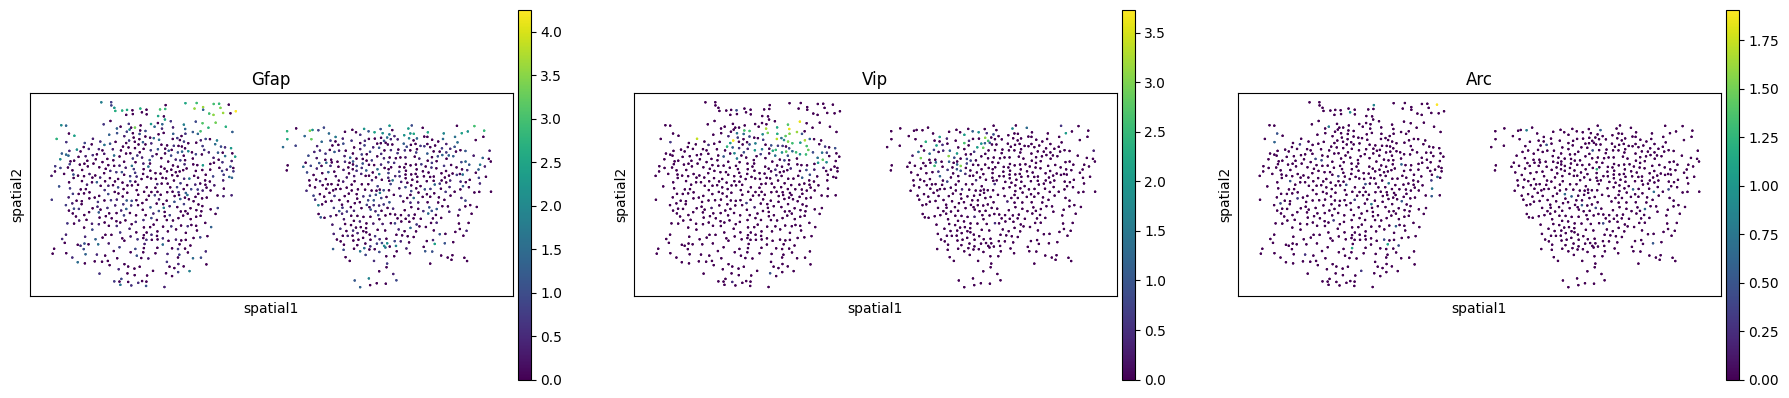

In [57]:
sq.pl.spatial_scatter(
    adata_sub,
    library_id="spatial",
    color=[
        "Gfap",
        "Vip",
        "Arc"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Tlr1",
        "Tlr6",
        "Tlr3"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gpr88",
        "Ppp3r1",
        "Foxj1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Sostdc1",
    ],
    shape=None,
    size=2,
    img=False,
)

## LigRec

In [140]:
adata_sub.raw = adata_sub.copy()

In [166]:
adata_sub.obs['cell_type_final'].value_counts(normalize=False)

cell_type_final
L6 IT CTX Glut           770
Astro TE                 429
L4 5 IT CTX Glut         411
Oligodendrocyte          281
L2 3 IT PIR ENTl Glut    199
L6 CT CTX Glut           189
Endothelial              164
Microglia                118
Pvalb Gaba                90
Sst Gaba                  64
OPC                       59
L5 ET CTX Glut            58
Pericyte                  57
L6b CTX Glut              43
CLA EPd CTX Glut          33
Lamp5 Gaba                29
L2 3 PIR ENTl Glut        26
Vip Gaba                  24
L5 NP CTX Glut            20
VLMC                      13
ABC                       13
COAa PAA MEA Glut          9
Sncg Gaba                  8
NLOT Glut                  6
L2 3 IT RSP Glut           6
DG Glut                    5
MEA Glut                   2
SMC                        2
STR PAL Gaba               1
Name: count, dtype: int64

In [149]:
sc.pp.subsample(adata_sub, fraction = 0.1) ### Will automatically replace adata_sub everytime you run it. Be carefull

In [150]:
adata_sub

AnnData object with n_obs × n_vars = 3129 × 5006
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_counts', 'batch', 'sample', 'mmc:class_name', 'mmc:class_correlation_coefficient', 'mmc:subclass_name', 'mmc:supertype_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'run', 'leiden', 'cell_type_auto', 'cell_class_auto', 'cell_type_newnum_auto', 'cell_class_newnum_auto', 'cell_type_auto_sub', 'cell_type_newnum_auto_sub', 'cell_type_final', 'cell_type_newnum_final', 'region_automap_name', 'region_automap_num', 'cell_class', 'cell_class_newnum', 'circascore', 'ZT', 'umap-1', 'umap-2', 'umap-3', 'umap-4',

In [151]:
sq.gr.ligrec(adata_sub,
             "cell_type_final",
            #  clusters = ("L6 CT CTX Glut", "Vip Gaba"),
             use_raw=True,
             complex_policy = "all",
            #  threshold = 0.5,
             corr_method = 'fdr_bh',
             alpha =0.01,
             n_jobs = 2,
             n_perms = 10000)

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/gr/_utils.py:136: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/gr/_ligrec.py:726: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby("clusters")


  0%|          | 0/10000 [00:00<?, ?permutation/s]

In [152]:
adata_sub.uns['cell_type_final_ligrec'].keys()

dict_keys(['means', 'pvalues', 'metadata'])

In [163]:
adata_sub.uns['cell_type_final_ligrec']['pvalues'].to_csv('data/LigRec_CTX_circa4_pvalues.csv')
#[('Oligodendrocyte','Oligodendrocyte')]

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/squidpy/pl/_ligrec.py:295: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for cls, size in (pvals.groupby(level=0, axis=1)).size().to_dict().items():
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


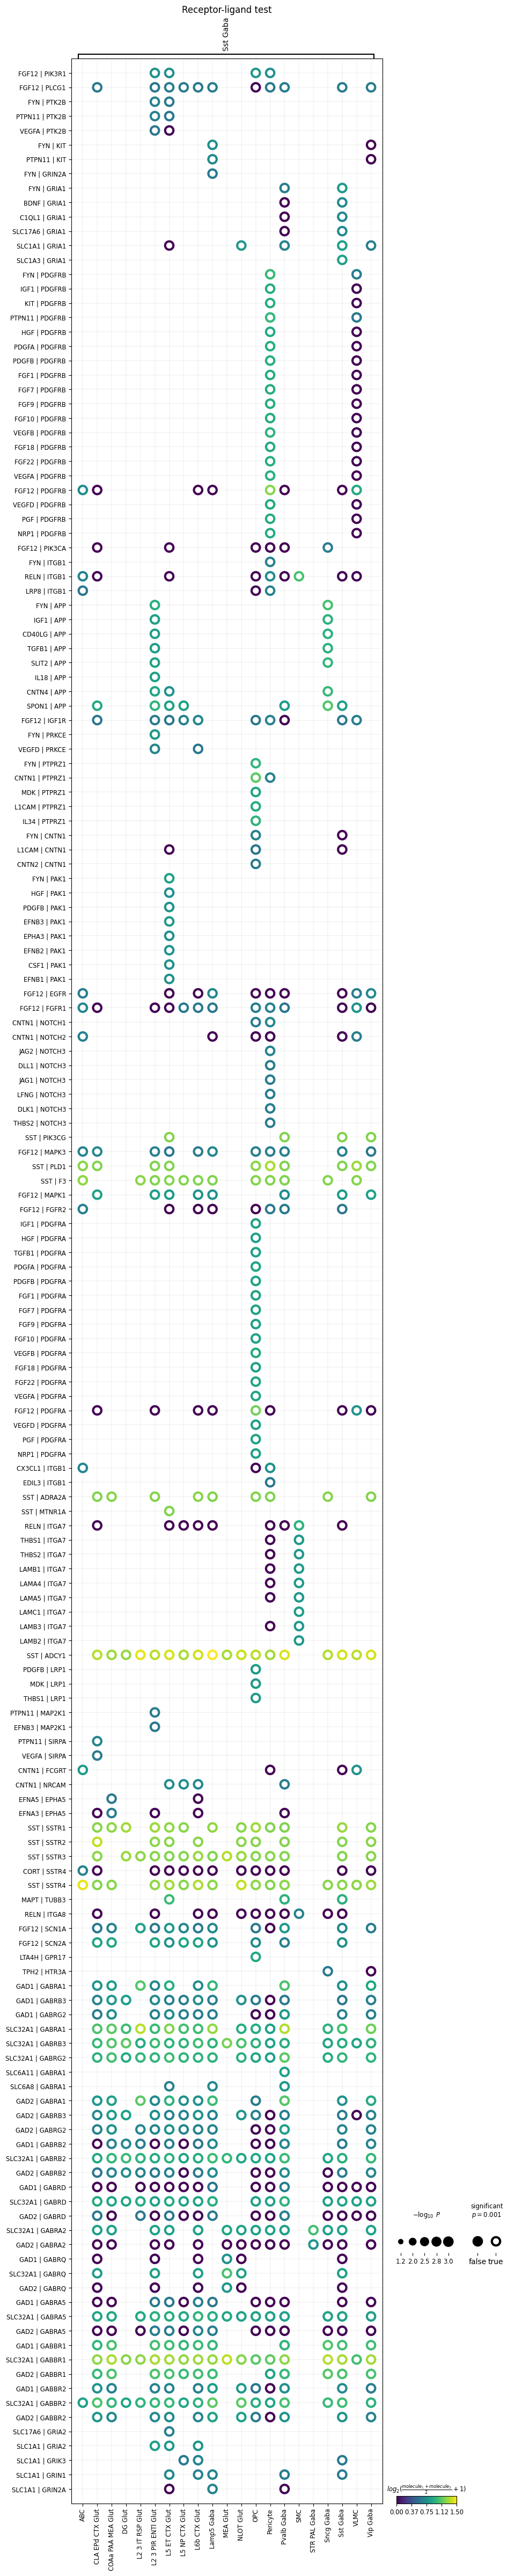

In [162]:
sq.pl.ligrec(adata_sub,
            source_groups="Sst Gaba",
            # target_groups= "Microglia",
            cluster_key='cell_type_final',
            remove_nonsig_interactions=True,
            alpha = 0.001,
            dendrogram= None,
            pvalue_threshold = 0.001,
            means_range = (0.5,1.9)
             )


# DEG

## Data import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
cell_nb = pd.read_csv(f'{dir_notebook}/analysis/circa-SD/summary_cell_number.csv')
cell_nb

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Jupyter_notebook\\Xenium_jupyter_notebook/analysis/circa-SD/summary_cell_number.csv'

In [ ]:
from module.misc import cell_class

dict_temp = cell_class()

cell_nb['cell_class'] = cell_nb['cell_type_final'].apply(lambda x: dict_temp[x] if x in dict_temp.keys() else "Neuron")
cell_nb

In [ ]:
plt.figure(figsize=(15,5))
plt.bar(x=cell_nb['cell_type_final'][cell_nb['run']=='circa4'],
         height=cell_nb[cell_nb['run']=='circa4']['count'],
           width = 0.5, align='edge', edgecolor ='black')
plt.bar(x=cell_nb['cell_type_final'][cell_nb['run']=='SD1'],
         height=cell_nb[cell_nb['run']=='SD1']['count'],
           width = -0.5, align='edge', edgecolor ='black')
plt.xticks(ticks=cell_nb['cell_type_final'][cell_nb['run']=='SD1'], rotation=90)
plt.savefig('Gallery/circa-SD_cellnb.svg')

## Cell pop hierarchical order

In [10]:
cell_pop = pd.read_csv('../notebook/analysis/circa-SD/circa-SD_cellpop.csv')
# circa_pct = pd.read_csv('../notebook/analysis/circa-SD/circa-SD_circa-percent.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../notebook/analysis/circa-SD/circa-SD_cellpop.csv'

In [11]:
cell_pop.sort_values(by='cell_type_final', inplace=True, ignore_index=True)
# circa_pct.sort_values(by='cell_type_final', inplace=True, ignore_index=True)

NameError: name 'cell_pop' is not defined

In [ ]:
from module.misc import genes_list

clock_genes = genes_list('clock')
df_CG = df.filter(clock_genes, axis = 1)

In [ ]:
df_CG['cell_type_final'] = df['cell_type_final']
df_CG.sample() 

In [ ]:
grouped = df.groupby('cell_type_final')[clock_genes].mean()

In [ ]:
order_list = [
    "Oligodendrocyte","Microglia","Endothelial","SMC","Pericyte","VLMC","ABC","Choroid","Ependymal","Tanycyte","OB STR CTX IMN","OPC","Astro TE",
    "SCH Gaba","PVH Glut","HY Glut","SPA Glut","AHN Glut","PVT Glut","PAL STR Gaba Chol","MEA Glut","MPO Glut","BST Glut","LHA Glut","LH Glut",
    "BAC Glut","TRS BAC Glut","MH Glut","AV Glut","VM MD Glut","LD Glut","VP Glut","SMT Glut","CM Glut","RE Glut","PT Glut","AD Glut","RT ZI Gaba",
    "Pvalb Gaba","STR Gaba","Sst Gaba","Sncg Gaba","Vip Gaba","Lamp5 Gaba","L6 IT CTX Glut","L4 5 IT CTX Glut","L2 3 IT RSP Glut","L5 ET CTX Glut",
    "L5 NP CTX Glut","L6b CTX Glut","L6 CT CTX Glut","CLA EPd CTX Glut","L2 3 PIR ENTl Glut","NLOT Glut","L2 3 IT PIR ENTl Glut","COAa PAA MEA Glut",
    "CA3 Glut","CA2 FC IG Glut","CA1 ProS Glut","DG Glut","STR PAL Gaba","LSX Gaba","STR D1 Gaba","STR D2 Gaba",
]

cell_pop["Celltype_order"] = pd.Categorical(cell_pop["cell_type_final"], categories=order_list, ordered = True)
cell_pop.sort_values('Celltype_order', inplace= True)

grouped_sort = grouped.reindex(order_list)
grouped_sort

In [ ]:
cell_pop

In [ ]:
import seaborn as sns

plt.figure(figsize=(2,10))

plt.barh(y=cell_pop['cell_type_final'],
         width=cell_pop['count'],
           height = 0.8, align='edge', edgecolor ='black')
plt.xscale('log')
plt.ylim(-1,len(cell_pop))

# ax[1].barh(y=cell_pop['cell_type_final'],
#          width=cell_pop['circascore'],
#            height = 0.8, align='edge', edgecolor ='black')
# ax[1].set_yticks([])
# ax[1].set_ylim(-1,len(cell_pop))
plt.savefig('Gallery/cellpop.svg', dpi=300)

## Data import DEG celltype

In [156]:
# dir_notebook = 'D:\\Jupyter_notebook\\Xenium_jupyter_notebook'

df_all = pd.read_excel(f'{dir_notebook}/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if "SD1" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_expressed[key] = df_all[key][
        # (df_all[key]['pct_nz_group']>0.1) &
          df_all[key]['mean_count']>= 0.01
          ]
    df_all[key].index = df_all[key]['names']

In [ ]:
df_filter = pd.read_excel('../notebook/analysis/circa-SD/DEG_celltype_filter.xlsx', sheet_name=None)

for key in df_filter.keys():
    df_filter[key] = df_filter[key][df_filter[key]['group'] == 'SD1']
    df_filter[key].index = df_filter[key]['names']

In [157]:
### Alternative filtering
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0.0)
                                 & (df_all[key]['pct_nz_reference'] > 0)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >= 0.01)
                                 ]
# df_filter['SCH'].sort_values(by='logfoldchanges')

### All DEG

In [158]:
list_of_DEG = []
for key in df_filter:
    list_temp = list(df_filter[key]['names'])
    list_of_DEG.extend(list_temp)

In [159]:
unique_gene = set(list_of_DEG)
count_dict = {}
for gene in unique_gene:
    count_dict[gene] = list_of_DEG.count(gene)

In [160]:
df = pd.DataFrame(data ={"Gene": list(unique_gene)})

In [161]:
df['count'] = df['Gene'].map(count_dict)
df.sort_values(by='count', inplace = True, ascending = False)
df.shape

(3687, 2)

In [162]:
df.sort_values(by='count')

,Gene,count
1882,Sec23a,1
1244,Usp7,1
3593,Stom,1
3449,Dvl2,1
1383,Casc4,1
...,...,...
52,Sptbn2,54
2100,Atp6ap2,55
3521,Mbd5,55
263,Eif2a,57


In [212]:
mean_exp = pd.DataFrame(columns=['Gene','mean_count'])
a = 0
for key in df_filter.keys():
    for gene in df_filter[key]['names']:
        temp_count = df_filter[key]['mean_count'][gene]
        mean_exp.loc[a] = [gene, temp_count]
        a +=1

In [214]:
mean_exp = mean_exp.groupby('Gene')['mean_count'].mean()
mean_exp.head()

Gene
A2m      0.036394
Aatf     0.068935
Abca1    0.034477
Abca3    0.295016
Abca4    0.365732
Name: mean_count, dtype: float64

In [215]:
dict_mean_exp = dict(zip(mean_exp.index,mean_exp.values))

Text(0.5, 0, 'Number of celltypes')

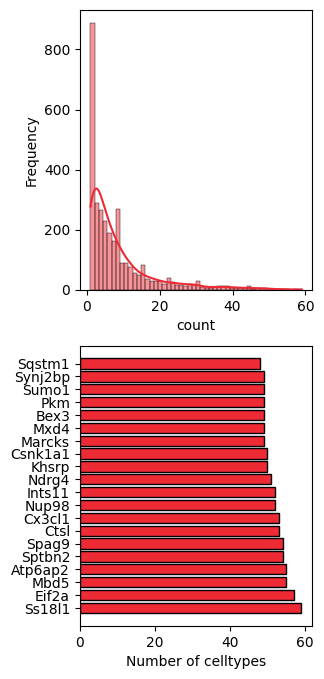

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1, figsize=(3,8))
ax = ax.flatten()
ax[1].barh(y=df['Gene'][0:20], height=0.8, width=df['count'][0:20], edgecolor = 'black')
# plt.hist(x=df['count'])
sns.histplot(df['count'], element="bars", cumulative= False, fill= True, common_norm=False,kde = True,
             stat='frequency', ax=ax[0])
plt.xlabel('Number of celltypes')
# plt.yscale("log")

In [164]:
from module.misc import cell_class
dict_cellclass = cell_class()

list_of_celltype = [key for key in df_filter.keys()]
df_celltype = pd.DataFrame(data = {'Celltype' : list_of_celltype})
df_celltype['Cellclass'] = df_celltype['Celltype'].apply(lambda x: dict_cellclass[x] if x in dict_cellclass.keys() else "Neuron")
df_celltype.sample(5)

,Celltype,Cellclass
26,L2 3 PIR ENTl Glut,Neuron
31,COAa PAA MEA Glut,Neuron
30,Pvalb Gaba,Neuron
1,BST Glut,Neuron
18,LSX Gaba,Neuron


In [165]:
from module.misc import genes_list

gene_index = genes_list('panel_5k')

matrix = pd.DataFrame(data = {'Neuron':np.zeros(5006),
                              "Glial" : np.zeros(5006),
                              'Vascular': np.zeros(5006),
                              'Ependymal': np.zeros(5006)}, index = gene_index)

class_list = df_celltype.groupby('Cellclass')['Celltype'].unique()

for nb, class_ in enumerate(class_list):
    class_for_matrix = class_list.index[nb]
    for celltype_ in class_:
        list_temp = list(df_filter[celltype_]['names'])
        for gene in list_temp:
            matrix.loc[gene,class_for_matrix] += 1


matrix['total'] = matrix.sum(axis=1)
matrix.sort_values(by='total', ascending = False, inplace= True)

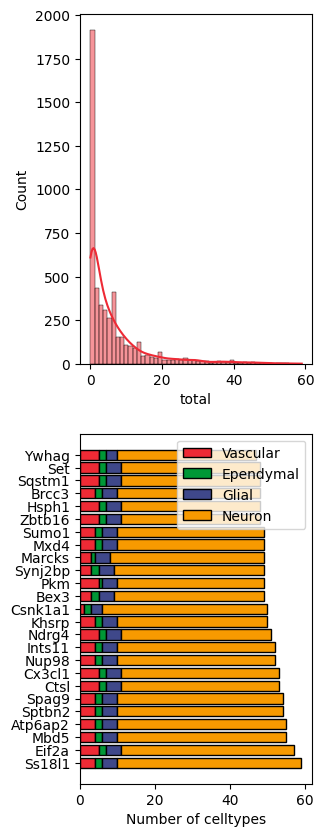

In [193]:
y1 = matrix['Vascular'][0:25]
y2 = matrix['Ependymal'][0:25]
y3 = matrix['Glial'][0:25]
y4 = matrix['Neuron'][0:25]

y1b = matrix_bis['Vascular'][-25:-1]
y2b = matrix_bis['Ependymal'][-25:-1]
y3b = matrix_bis['Glial'][-25:-1]
y4b = matrix_bis['Neuron'][-25:-1]




import seaborn as sns
fig, ax = plt.subplots(2,1, figsize=(3,10))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [217]:
matrix_bis = matrix[matrix['total']!=0]
matrix_bis['mean_count'] = matrix_bis.index.map(dict_mean_exp)
matrix_bis

/tmp/ipykernel_162254/2280226216.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matrix_bis['mean_count'] = matrix_bis.index.map(dict_mean_exp)


,Neuron,Glial,Vascular,Ependymal,total,mean_count
Ss18l1,49.0,4.0,4.0,2.0,59.0,0.129000
Eif2a,46.0,4.0,5.0,2.0,57.0,0.100662
Mbd5,45.0,4.0,4.0,2.0,55.0,0.037141
Atp6ap2,45.0,4.0,4.0,2.0,55.0,0.560386
Sptbn2,44.0,4.0,4.0,2.0,54.0,0.194655
...,...,...,...,...,...,...
Thrap3,1.0,0.0,0.0,0.0,1.0,0.238663
Mdm2,1.0,0.0,0.0,0.0,1.0,0.093785
Slc11a2,0.0,0.0,0.0,1.0,1.0,0.083363
En2,0.0,1.0,0.0,0.0,1.0,0.025848


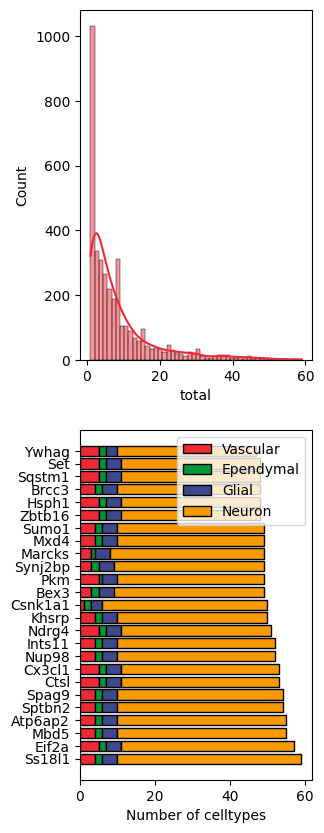

In [195]:
y1 = matrix_bis['Vascular'][0:25]
y2 = matrix_bis['Ependymal'][0:25]
y3 = matrix_bis['Glial'][0:25]
y4 = matrix_bis['Neuron'][0:25]

y1b = matrix_bis['Vascular'][-25:-1]
y2b = matrix_bis['Ependymal'][-25:-1]
y3b = matrix_bis['Glial'][-25:-1]
y4b = matrix_bis['Neuron'][-25:-1]




import seaborn as sns
fig, ax = plt.subplots(2,1, figsize=(3,10))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix_bis['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



(array([2.982e+03, 4.960e+02, 1.180e+02, 4.900e+01, 2.200e+01, 8.000e+00,
        7.000e+00, 2.000e+00, 1.000e+00, 2.000e+00]),
 array([0.01000377, 0.1910334 , 0.37206303, 0.55309267, 0.7341223 ,
        0.91515193, 1.09618157, 1.2772112 , 1.45824083, 1.63927047,
        1.8203001 ]),
 <BarContainer object of 10 artists>)

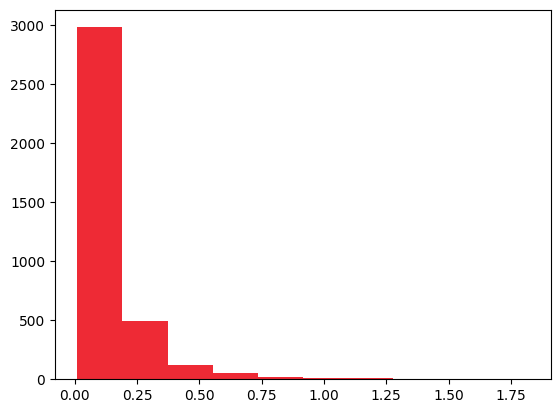

In [220]:
# plt.scatter(x= matrix_bis['mean_count'], y = matrix_bis['total'])
plt.hist(matrix_bis['mean_count'])

## Quantif

In [10]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant

,Celltype,Expressed,nb_DEG,Upregulated,Downregulated
Celltype,,,,,
Astro TE,Astro TE,3186,514,142,372
BST Glut,BST Glut,3004,1276,707,569
Vip Gaba,Vip Gaba,2993,445,120,325
Sst Gaba,Sst Gaba,2946,530,151,379
PVH Glut,PVH Glut,3067,415,185,230
...,...,...,...,...,...
LD Glut,LD Glut,2814,590,543,47
LH Glut,LH Glut,2941,212,178,34
MH Glut,MH Glut,2995,665,655,10


In [11]:
### Region only, remove liminal celltypes
# df_deg_quant.drop(['VLMC', "Ependymal","Choroid",'Tanycyte'], axis = 0, inplace=True)

### Celltypes only, remove tanycyte
df_deg_quant.drop(['Tanycyte'], axis = 0, inplace=True)

In [186]:
order_list = [
    "Oligodendrocyte","Microglia","Endothelial","SMC","Pericyte","VLMC","ABC","Choroid","Ependymal","Tanycyte","OB STR CTX IMN","OPC","Astro TE",
    "SCH Gaba","PVH Glut","HY Glut","SPA Glut","AHN Glut","PVT Glut","PAL STR Gaba Chol","MEA Glut","MPO Glut","BST Glut","LHA Glut","LH Glut",
    "BAC Glut","TRS BAC Glut","MH Glut","AV Glut","VM MD Glut","LD Glut","VP Glut","SMT Glut","CM Glut","RE Glut","PT Glut","AD Glut","RT ZI Gaba",
    "Pvalb Gaba","STR Gaba","Sst Gaba","Sncg Gaba","Vip Gaba","Lamp5 Gaba","L6 IT CTX Glut","L4 5 IT CTX Glut","L2 3 IT RSP Glut","L5 ET CTX Glut",
    "L5 NP CTX Glut","L6b CTX Glut","L6 CT CTX Glut","CLA EPd CTX Glut","L2 3 PIR ENTl Glut","NLOT Glut","L2 3 IT PIR ENTl Glut","COAa PAA MEA Glut",
    "CA3 Glut","CA2 FC IG Glut","CA1 ProS Glut","DG Glut","STR PAL Gaba","LSX Gaba","STR D1 Gaba","STR D2 Gaba",
]

df_deg_quant["Celltype_order"] = pd.Categorical(df_deg_quant["Celltype"], categories=order_list, ordered = True)
df_deg_quant.sort_values('Celltype_order', inplace= True)
df_deg_quant.dropna(axis = 0, inplace= True)

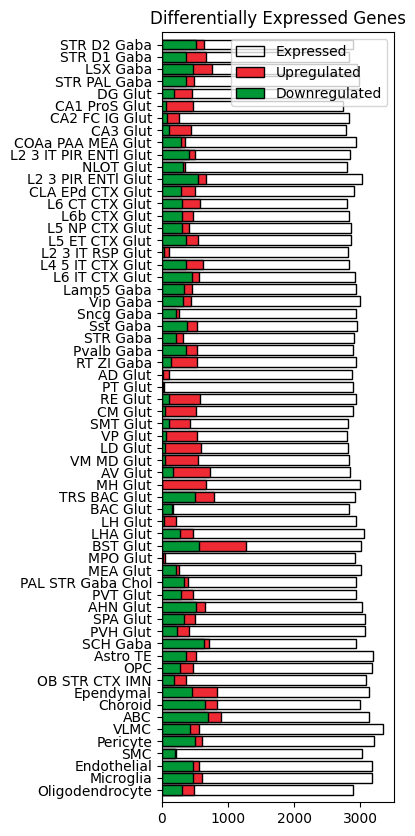

In [187]:
plt.figure(figsize=(3,10))
# df_deg_quant.sort_values(by='Downregulated', inplace=True)
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Expressed'], height = 0.8, color =[], edgecolor = 'black', label = 'Expressed')
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['nb_DEG'], height = 0.8, edgecolor = 'black', label = "Upregulated")
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Downregulated'], height = 0.8, edgecolor = 'black', label = 'Downregulated')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')
plt.legend()
plt.ylim(-1,len(df_deg_quant))
plt.title(f'Differentially Expressed Genes')
plt.savefig(f'Gallery/{today}/DEG_per_celltype.svg', dpi = 300)

## Volcano plot

In [ ]:
key = 'Astro TE'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
# for idx, gene in enumerate(df_filter[key][df_filter[key]['logfoldchanges']>0]['names']):
#     plt.text(df_filter[key]['logfoldchanges'][idx], df_filter[key]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title("DEG: Astrocytes - Whole Brain")
# plt.savefig('Gallery/volcano_plot_SCN.svg')

In [ ]:
df_filter[key].index = df_filter[key]['names']

## DEG all celltypes in one region

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

directory_DEG = '../notebook/analysis/circa-SD/foldchanges/celltype_in_region'
region_of_interest = 'CTX'

df_all = pd.read_excel(f'{directory_DEG}/{region_of_interest}_all_celltypes_DEG.xlsx', sheet_name=None)

In [ ]:
df_expressed = {}
for key in df_all.keys():
    if "SD1" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_expressed[key] = df_all[key][(df_all[key]['pct_nz_group']>0.1) & df_all[key]['mean_count']>= 0.01]
    df_all[key].index = df_all[key]['names']

In [ ]:
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0)
                                 & (df_all[key]['pct_nz_reference'] > 0)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >= 0.01)
                                 ]

In [ ]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant.sort_values(by='nb_DEG', ascending = False)

In [ ]:
key = 'Vip Gaba'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
# for idx, gene in enumerate(df_filter[key][df_filter[key]['logfoldchanges']>0]['names']):
#     plt.text(df_filter[key]['logfoldchanges'][idx], df_filter[key]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title(f"DEG: {key} - {region_of_interest}")
plt.savefig(f'Gallery/volcano_plot_{key}_{region_of_interest}.svg', dpi= 300)

## DEG celltype in diff regions

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

directory_DEG = '../notebook/analysis/circa-SD/foldchanges/celltype_in_region/'
all_regions = os.listdir(directory_DEG)

In [ ]:
all_regions =  [region for region in all_regions if region.split('_')[-1] == 'DEG.xlsx' ]
# all_regions.remove('MEA_all_celltypes_DEG.xlsx')
all_regions

In [ ]:
cell_type_inregion = "Microglia"
celltype_inregion_DEG = {}
for file in all_regions:
    region = file.split("_")[0]
    print(region)
    df = pd.read_excel(f'{directory_DEG}{file}', sheet_name= None)
    celltype_inregion_DEG[region] = df[cell_type_inregion]

In [ ]:
celltype_inregion_DEG = {key:val for key, val in celltype_inregion_DEG.items() if len(val)  > 1}

In [ ]:
for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG[key] = celltype_inregion_DEG[key][celltype_inregion_DEG[key]['group'] == 'SD1']
    celltype_inregion_DEG[key].index = celltype_inregion_DEG[key]['names']

celltype_inregion_DEG_filter = {}

for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG_filter[key] = celltype_inregion_DEG[key][(celltype_inregion_DEG[key]['pvals_adj'] < 0.05)
                                        #    & (celltype_inregion_DEG[key]['pct_nz_group'] > 0.15)
                                           & (abs(celltype_inregion_DEG[key]['logfoldchanges']) > 0.26)
                                           & (celltype_inregion_DEG[key]['mean_count'] > 0.01)
                                           ]

In [ ]:
deg_quant = [len(celltype_inregion_DEG_filter[key]) for key in celltype_inregion_DEG_filter.keys()]
deg_up = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]) for key in celltype_inregion_DEG_filter.keys()]
deg_down = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]) for key in celltype_inregion_DEG_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Region' : celltype_inregion_DEG_filter.keys(),
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Region']
df_deg_quant.drop(['VLMC','Ependymal'], axis=0, inplace=True)
df_deg_quant

In [ ]:
plt.figure(figsize=(3,3))
df_deg_quant.sort_values(by='nb_DEG', inplace=True)
plt.barh(y = df_deg_quant['Region'], width=df_deg_quant['Upregulated'], edgecolor ='black')
plt.barh(y = df_deg_quant['Region'], width=-df_deg_quant['Downregulated'], edgecolor ='black')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')
plt.ylim(-0.5, len(df_deg_quant)-0.5)
plt.title('DEG: {cell_type_inregion} in different regions')

In [ ]:
celltype_inregion_DEG_filter['SCH'].sort_values(by="logfoldchanges")

In [ ]:
key = 'SCH'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=celltype_inregion_DEG_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=celltype_inregion_DEG[key]['logfoldchanges'], y = celltype_inregion_DEG[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= celltype_inregion_DEG_filter[key]['logfoldchanges'], y=celltype_inregion_DEG_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
# for idx, gene in enumerate(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges']>0]['names']):
#     plt.text(celltype_inregion_DEG_filter[key]['logfoldchanges'][idx], celltype_inregion_DEG_filter[key]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-4,4)
# plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.title(f'DEG: {cell_type_inregion} in {key}')
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
# plt.savefig('Gallery/volcano_plot_SCN.svg')

In [ ]:
list_genes = set(celltype_inregion_DEG_filter[key]['names'].values)
for key in celltype_inregion_DEG_filter.keys():
    print(key)
    temp = set(celltype_inregion_DEG_filter[key]['names'].values)
    list_genes = list_genes.intersection(temp)
len(list_genes)


In [ ]:
temp = set("Sod1")

In [ ]:
set(celltype_inregion_DEG_filter['SCH']['names'].values)

## GO analysis

### Pre-process

In [ ]:
## Download ontologies from http://geneontology.org/ontology/go-basic.obo
## Download associations from ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz

from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader

# obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")



In [ ]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples

objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

for nspc, id2gos in ns2assoc.items():
    print("{NS} {N:,} annotated mouse genes".format(NS=nspc, N=len(id2gos)))

In [ ]:
from module.genes_ncbi_mouse_proteincoding import GENEID2NT as GeneID2nt_mouse

print(len(GeneID2nt_mouse))

In [ ]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method



In [ ]:
## Get all the go items including those appears multiple times

GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [ ]:
## Build mapping dictionaries between gene id and gene symbols

id_mapper = {}

for key in GeneID2nt_mouse:
    id_mapper[GeneID2nt_mouse[key].Symbol] = GeneID2nt_mouse[key].GeneID
    
rev_mapper = {v: k for k, v in id_mapper.items()} 

In [ ]:
import numpy as np

def go_analysis(gene_list):
    
    mapped_gene = []

    for gene in gene_list:
        try:
            mapped_gene.append(id_mapper[gene])
        except:
            pass 
    
    goea_results_all = goeaobj.run_study(mapped_gene)  
    
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.05]
    
    
    df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

    df_go = df_go[df_go.n_genes > 1]
    df_go['LogP'] = -np.log10(df_go['p'])
    return df_go

### Process

In [ ]:
target_genes_up = list(celltype_inregion_DEG_filter['SCH'][celltype_inregion_DEG_filter['SCH']['logfoldchanges'] > 0]['names'])
target_genes_down = list(celltype_inregion_DEG_filter['SCH'][celltype_inregion_DEG_filter['SCH']['logfoldchanges'] < 0]['names'])

In [ ]:
target_genes_up = list(df_filter[key][df_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(df_filter[key][df_filter[key]['logfoldchanges'] < 0]['names'])

In [ ]:
target_genes_up = [id_mapper[gene] for gene in target_genes_up if gene in id_mapper]
target_genes_down = [id_mapper[gene] for gene in target_genes_down if gene in id_mapper]



goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction methodgoea_results_all = goeaobj.run_study()

goea_results_up = goeaobj.run_study(target_genes_up)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_up = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_down = goeaobj.run_study(target_genes_down)
goea_results_down_sig = [r for r in goea_results_down if r.p_fdr_bh<0.01]

df_go_down = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_down_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

                        

### GO plot

In [ ]:
df_go_up

In [ ]:
df_go_down

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

plt.figure(figsize=(2,3),dpi=300)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams["font.size"] = 10


up_labels = [s for s in df_go_up['term'][0:5]][::-1]
up_ngenes = [s for s in df_go_up['n_genes'][0:5]][::-1]
up_pvalues = [-np.log10(p) for p in df_go_up['p_corr'][0:5]][::-1]
up_ycor = [0.1*n for n in range(1,len(up_labels)+1)]

down_labels = [s for s in df_go_down['term'][0:5]][::-1]
down_ngenes = [s for s in df_go_down['n_genes'][0:5]][::-1]
down_pvalues = [-np.log10(p) for p in df_go_down['p_corr'][0:5]][::-1]
down_ycor = [0.1*n for n in range(len(down_labels)+1,len(down_labels)+len(up_labels)+1)]

#print(len(y_cor),len(labels),len(p_values))

plt.barh(up_ycor,up_pvalues,height=0.05, color = 'red', label = 'Upregulated')

plt.barh(down_ycor,down_pvalues,height=0.05, color = 'blue', label = 'Downregulated')

plt.yticks(up_ycor+down_ycor,[textwrap.fill(e,40) for e in up_labels+down_labels],fontsize=8)

for x,gene in enumerate(up_ngenes):
    plt.text(up_pvalues[x] + 0.5, up_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

for x,gene in enumerate(down_ngenes):
    plt.text(down_pvalues[x] + 0.5, down_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

#plt.yticks()
plt.xticks([0,3.0,6.0])
plt.xlabel('-log10(p_value)')

plt.savefig(f'Gallery/GO_{region_of_interest}_{key}',dpi=300,bbox_inches='tight')
plt.legend(markerscale=20, bbox_to_anchor=(1.02, 1), loc='lower left', borderaxespad=0)
plt.show()

In [ ]:
print(*df_go[df_go['term']=="neuromuscular process controlling balance"]["study_genes"])